
--- ЕТАП 1: ЗАВАНТАЖЕННЯ ДАНИХ ---

--- ЕТАП 2: ПОПЕРЕДНЯ ОБРОБКА ДАНИХ ---
Цільова змінна 'num' конвертована в бінарний формат (0/1).
Закодовано категоріальні ознаки: ['sex', 'cp', 'restecg', 'slope', 'thal']

--- ЕТАП 3: ПІДГОТОВКА ДАНИХ ---
Дані розділені та масштабовані.

--- ЕТАП 4: ТРЕНУВАННЯ МОДЕЛЕЙ ---

--- Оцінка моделі: Logistic Regression ---
Accuracy     0.826087
Precision    0.824074
Recall       0.872549
F1-score     0.847619
AUC-ROC      0.900646
dtype: float64


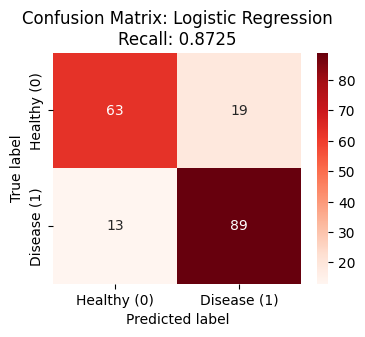

Хибно-негативні (FN): 13 (критична помилка).
------------------------------

--- Оцінка моделі: SVC (RBF) ---
Accuracy     0.836957
Precision    0.815789
Recall       0.911765
F1-score     0.861111
AUC-ROC      0.923123
dtype: float64


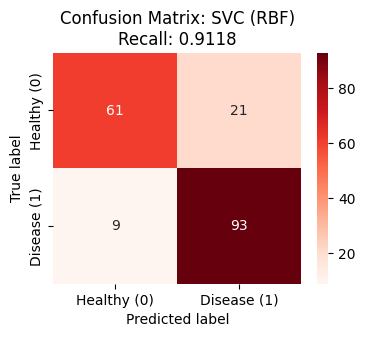

Хибно-негативні (FN): 9 (критична помилка).
------------------------------

--- Оцінка моделі: Random Forest ---
Accuracy     0.826087
Precision    0.824074
Recall       0.872549
F1-score     0.847619
AUC-ROC      0.908596
dtype: float64


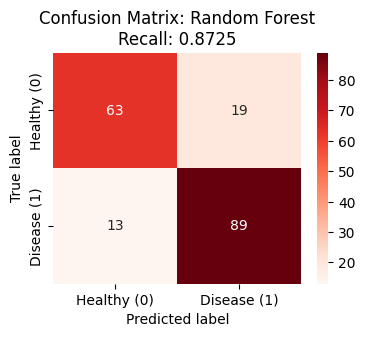

Хибно-негативні (FN): 13 (критична помилка).
------------------------------

--- ФІНАЛЬНЕ ПОРІВНЯННЯ МЕТРИК ---
                     Accuracy  Precision    Recall  F1-score   AUC-ROC
SVC (RBF)            0.836957   0.815789  0.911765  0.861111  0.923123
Random Forest        0.826087   0.824074  0.872549  0.847619  0.908596
Logistic Regression  0.826087   0.824074  0.872549  0.847619  0.900646


*** ВИСНОВОК ***
Пріоритет: Recall (мінімізація пропущених діагнозів).

Найкраща модель: **SVC (RBF)**.
Показник Recall: **0.9118**.
Показник AUC-ROC: **0.9231**.

--- КРИТИЧНА ІНФОРМАЦІЯ ДЛЯ API ---

УНІКАЛЬНІ ЗНАЧЕННЯ КАТЕГОРІАЛЬНИХ ЗМІННИХ:
  SEX: ['Male' 'Female']
  CP: ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
  RESTECG: ['lv hypertrophy' 'normal' 'st-t abnormality']
  SLOPE: ['downsloping' 'flat' 'upsloping']
  THAL: ['fixed defect' 'normal' 'reversable defect']

ФІНАЛЬНІ СТОВПЦІ ПІСЛЯ ONE-HOT ENCODING (18 ознак):
['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang'

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

warnings.simplefilter(action='ignore', category=FutureWarning)

def evaluate_heart_model(model_name, model, X_test, y_test, results_dict, X_test_for_proba):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test_for_proba)[:, 1] 
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    }
    results_dict[model_name] = metrics
    
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n--- Оцінка моделі: {model_name} ---")
    print(pd.Series(metrics))
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Healthy (0)', 'Disease (1)'],
                yticklabels=['Healthy (0)', 'Disease (1)'])
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(f'Confusion Matrix: {model_name}\nRecall: {metrics["Recall"]:.4f}')
    plt.show() 
    
    FN = cm[1, 0] 
    print(f"Хибно-негативні (FN): {FN} (критична помилка).")
    print("-" * 30)
    
    
# ==============================================================================
print("\n--- ЕТАП 1: ЗАВАНТАЖЕННЯ ДАНИХ ---")

data_path = '/kaggle/input/cursova123/heart_disease_uci.csv'
df_heart = pd.read_csv(data_path)

TARGET_COL = 'num' 

# ==============================================================================
print("\n--- ЕТАП 2: ПОПЕРЕДНЯ ОБРОБКА ДАНИХ ---")

df_heart = df_heart.drop(['id', 'dataset'], axis=1)
df_heart = df_heart.fillna(df_heart.mode().iloc[0]).infer_objects(copy=False)

if df_heart[TARGET_COL].nunique() > 2:
    df_heart[TARGET_COL] = df_heart[TARGET_COL].apply(lambda x: 1 if x > 0 else 0)
    print(f"Цільова змінна '{TARGET_COL}' конвертована в бінарний формат (0/1).")

categorical_cols = df_heart.select_dtypes(include='object').columns.tolist()

if 'fbs' in categorical_cols:
    df_heart['fbs'] = df_heart['fbs'].astype(int)
    categorical_cols.remove('fbs')

if categorical_cols:
    df_heart = pd.get_dummies(df_heart, columns=categorical_cols, drop_first=True)
    print(f"Закодовано категоріальні ознаки: {categorical_cols}")


# ==============================================================================
print("\n--- ЕТАП 3: ПІДГОТОВКА ДАНИХ ---")

X = df_heart.drop(TARGET_COL, axis=1)
y = df_heart[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Дані розділені та масштабовані.")
results = {}

# ==============================================================================
print("\n--- ЕТАП 4: ТРЕНУВАННЯ МОДЕЛЕЙ ---")

model_lr = LogisticRegression(random_state=42, max_iter=2000)
model_lr.fit(X_train_scaled, y_train)
evaluate_heart_model('Logistic Regression', model_lr, X_test_scaled, y_test, results, X_test_scaled)

model_svm_rbf = SVC(kernel='rbf', random_state=42, probability=True)
model_svm_rbf.fit(X_train_scaled, y_train)
evaluate_heart_model('SVC (RBF)', model_svm_rbf, X_test_scaled, y_test, results, X_test_scaled)

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train) 
evaluate_heart_model('Random Forest', model_rf, X_test, y_test, results, X_test) 

# ==============================================================================
print("\n--- ФІНАЛЬНЕ ПОРІВНЯННЯ МЕТРИК ---")

final_comparison = pd.DataFrame(results).T
final_comparison = final_comparison.sort_values(by=['Recall', 'AUC-ROC'], ascending=False)
print(final_comparison) 

print("\n\n*** ВИСНОВОК ***")
print("Пріоритет: Recall (мінімізація пропущених діагнозів).")

best_recall_model = final_comparison.index[0]
best_recall_value = final_comparison.iloc[0]['Recall']
best_auc_value = final_comparison.iloc[0]['AUC-ROC']

print(f"\nНайкраща модель: **{best_recall_model}**.")
print(f"Показник Recall: **{best_recall_value:.4f}**.")
print(f"Показник AUC-ROC: **{best_auc_value:.4f}**.")

print("\n--- КРИТИЧНА ІНФОРМАЦІЯ ДЛЯ API ---")

df_original = pd.read_csv(data_path)
df_original = df_original.drop(['id', 'dataset'], axis=1)
df_original = df_original.fillna(df_original.mode().iloc[0]).infer_objects(copy=False)

categorical_features = ['sex', 'cp', 'restecg', 'slope', 'thal']

print("\nУНІКАЛЬНІ ЗНАЧЕННЯ КАТЕГОРІАЛЬНИХ ЗМІННИХ:")
for col in categorical_features:
    if col in df_original.columns:
        unique_vals = df_original[col].unique()
        print(f"  {col.upper()}: {unique_vals}")

print("\nФІНАЛЬНІ СТОВПЦІ ПІСЛЯ ONE-HOT ENCODING (18 ознак):")
print(X_train.columns.tolist())